
# 1D EI showcase, from a saved checkpoint

Loads the trained `LayerLockedReadout` checkpoint from `notebooks/vla_readout_ei_fit.ipynb`'s
200,000-step run (`models/vla_readout_ei_fit.pt`) -- no retraining -- and plots its predicted EI
against the frozen PFN's own closed-form EI on a single, hand-picked 1D BNN draw with genuine
curvature. This is exactly the "different inference scenarios without retraining" use case
`save_checkpoint`/`load_checkpoint` (`models/layer_locked_readout.py`) were built for.

**A device/seed bug, fixed here:** the first version of this showcase (inline in
`vla_readout_ei_fit.ipynb`) built its illustrative 1D prior on whatever `device` the rest of that
notebook was using (`cuda`, on ulysses). `seed=42` was chosen by eyeballing a *CPU* preview
(`plot_1d_environments`) beforehand -- but CPU and CUDA are independent RNG streams in PyTorch,
so the same seed produces a *different* draw on each device. The GPU run silently plotted a
different (in this case, nearly flat and uninteresting) instance than the curvy one that was
actually picked. Fixed here by building `showcase_prior` on CPU unconditionally, independent of
whatever device the loaded readout happens to live on -- tensors are moved to the readout's device
only right before the model/readout calls that need it. This makes the choice of `seed` portable
across runs regardless of where they execute.


In [1]:

import matplotlib.pyplot as plt
import torch

from anytimeacquisition.models.layer_locked_readout import load_checkpoint
from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

readout, bar_dist_score, ckpt = load_checkpoint("../models/vla_readout_ei_fit.pt", device=device)
print("loaded readout, trained for", ckpt["metrics"]["n_steps"], "steps")
print("checkpoint metrics:", ckpt["metrics"])

# pfn_checkpoint_path was recorded relative to notebooks/ (where it was saved from) -- this
# notebook lives in the same directory, so it resolves directly, no rewriting needed.
model, _, pfn_ckpt = load_pfn_checkpoint(ckpt["pfn_checkpoint_path"], device=device)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)
X_DIM = pfn_ckpt["config"]["max_x_dim"]


/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded readout, trained for 200000 steps
checkpoint metrics: {'pooled_spearman': 0.9868546585406662, 'per_instance_spearman_mean': 0.931598240469208, 'per_instance_spearman_median': 0.9528958944281525, 'top1_hit_rate': 0.7, 'log10_r_error_mae': 0.10987663269042969, 'log10_r_error_rmse': 0.15840771794319153, 'final_ei_gap_mae': 0.0012993125536013394, 'final_val_nll': -0.6283525675535202, 'n_steps': 200000}


In [2]:

# showcase_prior is ALWAYS CPU, independent of `device` -- see intro markdown. Tensors move to
# `device` only right before the model/readout calls below need them.
SHOWCASE_DEVICE = "cpu"
showcase_prior = BNNPrior(
    batch_size=6, x_dim=1, ecdf_n_draws=50, ecdf_samples_per_draw=300, ecdf_n_samples=1000,
    cache_dir=None, seed=42, device=SHOWCASE_DEVICE,
)
ENV_IDX = 0  # previewed via plot_1d_environments(n_envs=6, seed=42) beforehand -- depth=9, width=110,
# a clean interior local dip nearly as good as the true optimum, picked before any prediction was run.

N_TRAIN_SHOWCASE = 6
showcase_gen = torch.Generator(device=SHOWCASE_DEVICE).manual_seed(7)
x_train_all, y_train_all, _, _ = showcase_prior.sample_episode(n_train=N_TRAIN_SHOWCASE, n_test=0, generator=showcase_gen)
x_train_sc, y_train_sc = x_train_all[ENV_IDX : ENV_IDX + 1], y_train_all[ENV_IDX : ENV_IDX + 1]  # [1, N_TRAIN, 1], [1, N_TRAIN]

x_grid = torch.linspace(0, 1, 300, device=SHOWCASE_DEVICE).view(1, 300, 1)
with torch.no_grad():
    y_grid_true = showcase_prior.evaluate(x_grid.expand(6, -1, -1), noise=False)[ENV_IDX]  # [300], the true curve


def pad_to_max_x_dim(x, max_x_dim):
    B, N, D = x.shape
    return x if D == max_x_dim else torch.cat([x, torch.zeros(B, N, max_x_dim - D, device=x.device)], dim=-1)


x_train_sc_p = pad_to_max_x_dim(x_train_sc, X_DIM).to(device)
x_grid_p = pad_to_max_x_dim(x_grid, X_DIM).to(device)
y_train_sc_d = y_train_sc.to(device)

with torch.no_grad():
    logits_frozen_sc, hidden_states_sc = model(x_train_sc_p, y_train_sc_d, x_grid_p, return_hidden=True)
    y_incumbent_sc = y_train_sc_d.min(dim=1).values
    incumbent_idx_sc = y_train_sc_d.argmin(dim=1)
    train_hidden_sc = [h[:, :N_TRAIN_SHOWCASE] for h in hidden_states_sc]

    ei_true_grid = model.bar_dist.ei(logits_frozen_sc, best_f=y_incumbent_sc.unsqueeze(-1))[0]  # [300]

    logits_pred_sc = readout(x_grid_p, train_hidden_sc, incumbent_idx_sc)
    r_pred_sc = 10.0 ** bar_dist_score.mean(logits_pred_sc)
    ei_pred_grid = (r_pred_sc * y_incumbent_sc.unsqueeze(-1))[0]  # [300]

x_grid_np = x_grid[0, :, 0].numpy()
y_grid_true_np = y_grid_true.numpy()
x_train_np, y_train_np = x_train_sc[0, :, 0].numpy(), y_train_sc[0].numpy()
incumbent_x = x_train_np[incumbent_idx_sc[0].item()]
ei_true_np, ei_pred_np = ei_true_grid.cpu().numpy(), ei_pred_grid.cpu().numpy()


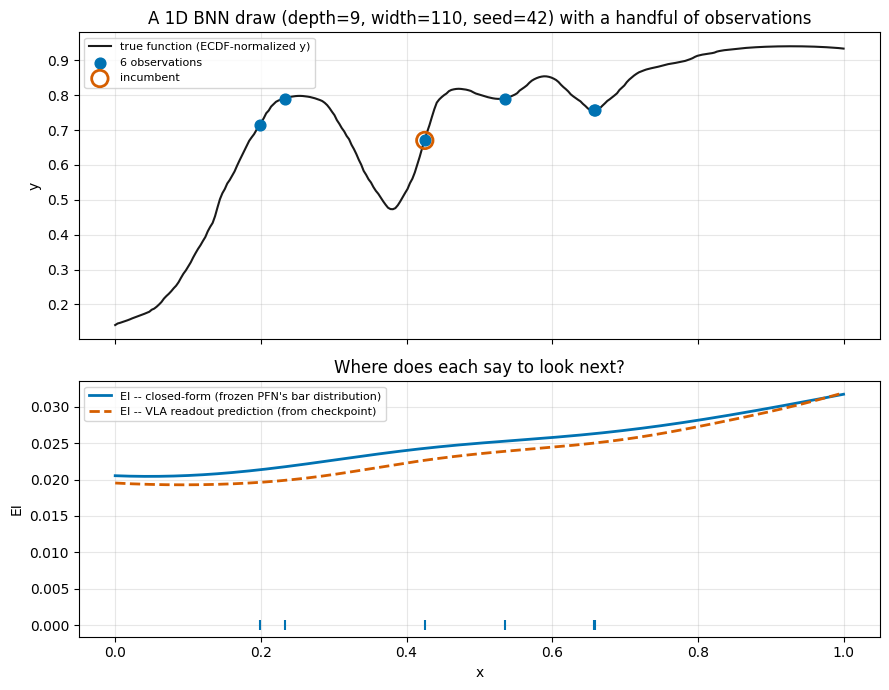

In [3]:

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, gridspec_kw={"height_ratios": [1.2, 1]})

axes[0].plot(x_grid_np, y_grid_true_np, color="#1a1a1a", linewidth=1.5, label="true function (ECDF-normalized y)")
axes[0].scatter(x_train_np, y_train_np, s=60, color="#0072B2", zorder=3, label=f"{N_TRAIN_SHOWCASE} observations")
axes[0].scatter([incumbent_x], [y_train_np.min()], s=140, facecolors="none", edgecolors="#D55E00",
                linewidths=2, zorder=4, label="incumbent")
axes[0].set_ylabel("y")
axes[0].set_title("A 1D BNN draw (depth=9, width=110, seed=42) with a handful of observations")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(x_grid_np, ei_true_np, color="#0072B2", linewidth=2, label="EI -- closed-form (frozen PFN's bar distribution)")
axes[1].plot(x_grid_np, ei_pred_np, color="#D55E00", linewidth=2, linestyle="--", label="EI -- VLA readout prediction (from checkpoint)")
axes[1].scatter(x_train_np, [0] * N_TRAIN_SHOWCASE, s=60, color="#0072B2", marker="|", zorder=3)
axes[1].set_xlabel("x")
axes[1].set_ylabel("EI")
axes[1].set_title("Where does each say to look next?")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig("_demo_plots/vla_readout_ei_showcase_1d.png", dpi=150, bbox_inches="tight")
plt.show()
